In [1]:
import batman
import emcee
import glob
import os
import shutil
import math
import corner
import numba
import itertools
import sys

import numpy       as np
import pandas      as pd
import time        as tm 
import lightkurve  as lk
# import mr_forecast as mr

import matplotlib                      as mpl
import matplotlib.pyplot               as plt
import matplotlib.gridspec             as gridspec
from   matplotlib.backends.backend_pdf import PdfPages
import mpl_axes_aligner


import astropy.io.fits    as apf
import astropy.units      as units
from   astropy.stats      import sigma_clip
from   astropy.wcs        import WCS
from   astropy.timeseries import BoxLeastSquares
from   astroquery.mast    import Catalogs
from   astroquery         import svo_fps

from multiprocessing import Pool, Process
from wotan           import flatten
from functools       import partial
from ldtk            import LDPSetCreator, BoxcarFilter, TabulatedFilter, SVOFilter
from ldtk.filters    import tess, sdss_z
from IPython.display import display, HTML
from tqdm.auto       import tqdm


# import eleanor

# import warnings
# warnings.filterwarnings("ignore")
# display(HTML("<style>.container { width:95% !important; }</style>"))
module_path = os.path.abspath(os.path.join('..', 'src'))
sys.path.insert(0, module_path)
from Functions_all import *
# from Executing_code_part_2_init_single_search import *
# from Executing_code_part_0_just_getting_data import *
# from Executing_code_part_2_init_single_search import *
from Executing_code_part_5_final_singles_search_and_figures import *
import gc



ModuleNotFoundError: No module named 'lpp_search'

In [3]:
import os
import deep_transit  # Replace with the name of your modulea


# Get the path to the module's directory
module_dir = os.path.dirname(deep_transit.__file__)
print(module_dir)

/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/deep_transit


In [6]:
for file in glob.glob('../toi_data/*/*.csv'):
    if '_flat' in file:
        os.remove(file)
        # break

In [ ]:
# import time
# from bs4 import BeautifulSoup

# import subprocess
# import requests



# url = 'https://archive.stsci.edu/hlsp/tglc'
# response = requests.get(url)a

# soup = BeautifulSoup(response.text, 'html.parser')
# # soup_list = soup.findAll('a', href=True, class_=False, target=False)[14:-2:2]

# # soup = BeautifulSoup(response.text, 'html.parser')
# soup_list = soup.findAll('a', href=True, class_=False, target=False)[14:-2:2]#[8:-2:2]

# len(soup_list)

In [ ]:
%%javascript
IPython.OutputArea.auto_scroll_threshold = 9999;



<IPython.core.display.Javascript object>

In [ ]:
missed = ['TIC 119584412','TIC 102734241', 'TIC 470381900', 'TIC 37749396', 'TIC 126606859', 'TIC 52005579', 'TIC 380887434', 'TIC 230055368',
 'TIC 240968774', 'TIC 18318288', 'TIC 261135533', 'TIC 305048087', 'TIC 289164482', 'TIC 163539739']


missed_ticids = [int(i[4:]) for i in missed]


multis = ['TIC 387690507', 'TIC 408636441', 'TIC 467179528', 'TIC 172370679', 'TIC 260708537', 'TIC 70899085', 'TIC 360156606', 
                 'TIC 29960110', 'TIC 296739893', 'TIC 181804752', 'TIC 306996324', 'TIC 336128819', 'TIC 28900646', 'TIC 246965431', 
                 'TIC 103633434', 'TIC 413248763', 'TIC 377293776', 'TIC 299798795', 'TIC 261257684', 'TIC 8348911', 'TIC 118327550',
                 'TIC 455784423', 'TIC 166184428', 'TIC 348755728', 'TIC 407591297', 'TIC 235678745', 'TIC 389900760', 'TIC 343628284', 
                 'TIC 351601843', 'TIC 396562848', 'TIC 4918918', 'TIC 271169413', 'TIC 44898913', 'TIC 201186294', 'TIC 353475866', 
                 'TIC 98796344', 'TIC 34068865', 'TIC 286201103', 'TIC 178709444', 'TIC 332657786', 'TIC 359271092', 'TIC 284441182']


multis_ticids = [int(i[4:]) for i in multis]


jovians =['TIC 95057860', 'TIC 46432937', 'TIC 459323923', 'TIC 163539739', 'TIC 445751830', 
          'TIC 419411415', 'TIC 382602147', 'TIC 243641947', 
          'TIC 172370679', 'TIC 308120029', 'TIC 119585136',  'TIC 459762279', 'TIC 67512645', 'TIC 360156606', 'TIC 387690507',
          'TIC 455784423', 'TIC 86263325', 'TIC 144700903', 
          'TIC 458419328', 'TIC 288144647']

jovian_ticids = [int(i[4:]) for i in jovians]


In [ ]:



lst_bad_file = [file for file in glob.glob('../toi_data/target*') if any(str(x) in file for x in jovian_ticids)]

target_files_lists = [i for i in range(len(glob.glob('../toi_data/target*'))) if glob.glob('../toi_data/target*')[i] in lst_bad_file]


In [ ]:

target_files_lists

[13, 17, 32, 33, 42, 60, 75, 103, 107, 108, 111, 112, 115, 121]

In [15]:
len(glob.glob('../toi_data/*'))


124

In [16]:
target_files = sorted(glob.glob('../toi_data/*'))

i = 0
for file in target_files:
    if '439456714' in file:
        print(i)
    i+=1



103


../toi_data/target_tic-95057860_gaiaID-2997312063605005056_data_check
95057860
running ticid 95057860
getting star params


  0%|          | 0/1 targets | 00:00<?

PERIODIC SEARCH
running search on all data
recursive BLS
max indx 0  len power results  115351
depth found 0.01971914446121982
mad 1.429357278617455e-05
Candidate: P=3.5819 d, SDE=45.46,min_SDE=10.00, SNR = 103.8239, min_SNR = 7.00


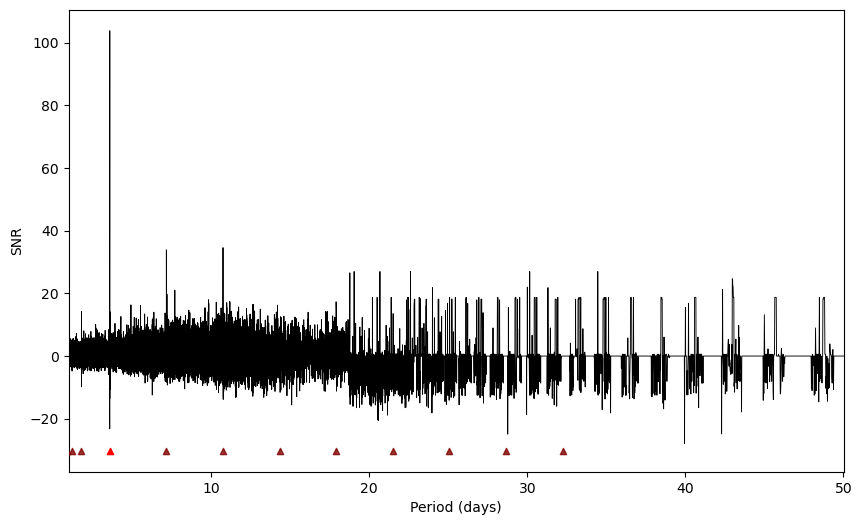

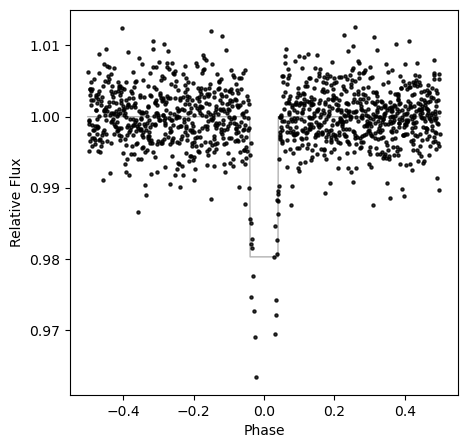

number transit times in baseline: 9  
number of point in each transit:  [1 1 4 5 2 3 2 2 2] 
transit likelihood: [ 1.96025574e-04  1.09064377e-04  8.53230814e-04  1.35054839e-03
  4.83762664e-04  7.47598044e-04  2.36763229e-04 -4.47167599e-05
  3.45014905e-04]
depths all [0.01971914446121982] transt durations:  [0.08]
Accepted planet: P=3.5819 d
max indx 0  len power results  115351
depth found 0.006707321519556265
mad 7.885072965055056e-06
Candidate: P=3.0611 d, SDE=7.98,min_SDE=10.00, SNR = 9.7766, min_SNR = 7.00


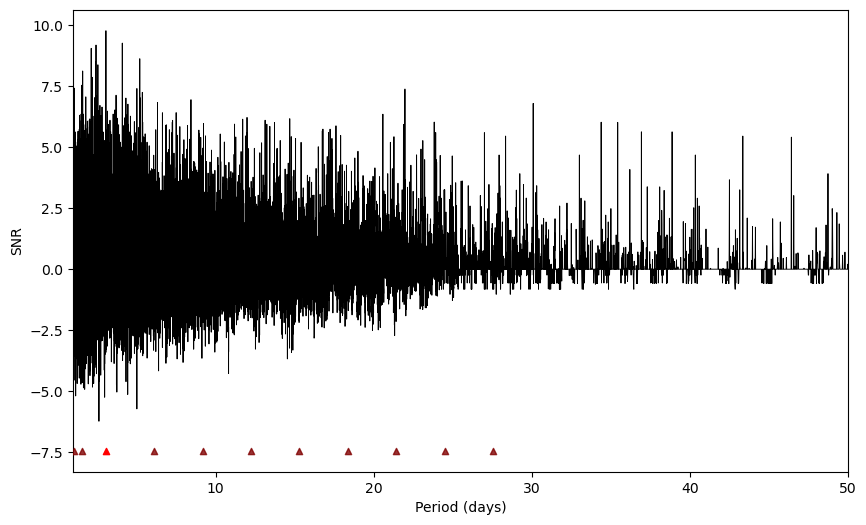

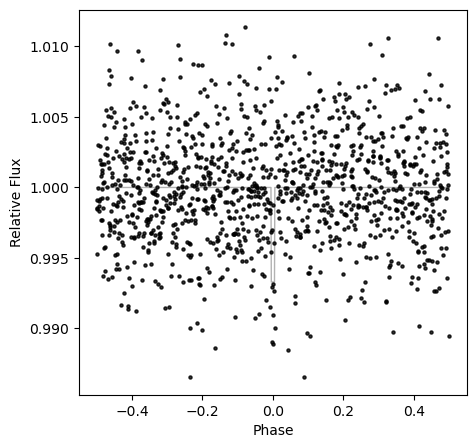

Stopping: SDE below threshold.
len(t0s) 1
3.581870499716538 <class 'numpy.float64'>
periodic, period = 3.581870499716538 days, transits observed =  12
N_intran 14 depth 0.03977715343061852 sig 1.3838253742891575e-05
folded: N_intran 0 depth 0.017262703435437173 sig 5.9181872932509746e-05
Sampling attempt 2...


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [t0, Per, a_rs, rp_rs, b]
/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/pytensor/configparser.py:317: UserWarning: PyTensor does not recognise this flag: lock_timeout
  warnings.warn(f"PyTensor does not recognise this flag: {key}")
/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/pytensor/configparser.py:317: UserWarning: PyTensor does not recognise this flag: lock_timeout
  warnings.warn(f"PyTensor does not recognise this flag: {key}")
/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/pytensor/configparser.py:317: UserWarning: PyTensor does not recognise this flag: lock_timeout
  warnings.warn(f"PyTensor does not recognise this flag: {key}")
/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/pytensor/configparser.py:317: UserWarning: PyTensor does not recognise this flag: lock_timeout
  warnings.wa

Output()

<IPython.core.display.HTML object>
<IPython.core.display.HTML object>
<IPython.core.display.HTML object>
<IPython.core.display.HTML object>


Sampling 4 chains for 6_000 tune and 15_000 draw iterations (24_000 + 60_000 draws total) took 51 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


checking nanas summary                  mean        sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  \
t0           1470.979     0.014  1470.971  1471.005      0.007    0.004   
Per             3.582     0.020     3.551     3.618      0.000    0.000   
a_rs           29.241    28.678    13.446    91.392     13.030    8.926   
rp_rs           0.153     0.008     0.133     0.166      0.003    0.002   
b               0.008     0.006     0.000     0.019      0.000    0.000   
depth           0.023     0.003     0.018     0.027      0.001    0.001   
cosi            0.000     0.000     0.000     0.001      0.000    0.000   
inclination    89.974     0.024    89.928    90.000      0.006    0.000   
tau             0.010     0.004     0.002     0.013      0.002    0.001   
dur             0.074     0.032     0.014     0.095      0.016    0.009   
win             0.149     0.064     0.027     0.191      0.031    0.018   
norm            1.000     0.000     1.000     1.000      0.000    0.000   
SN

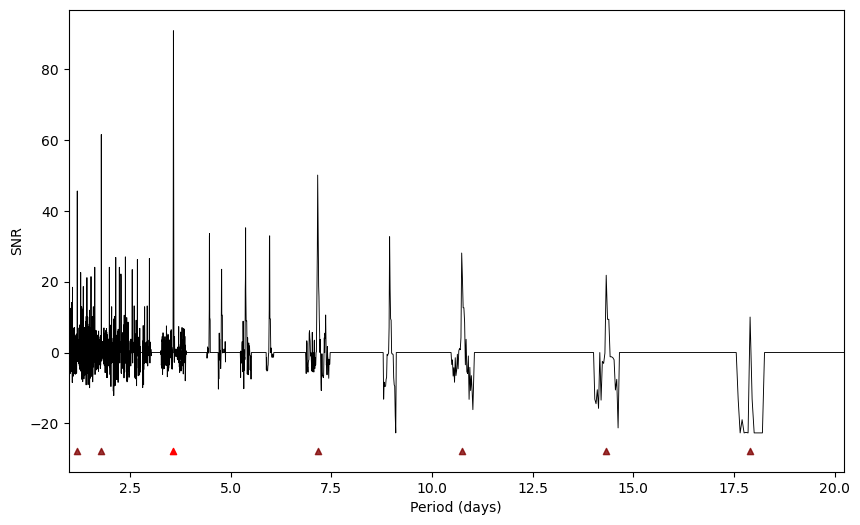

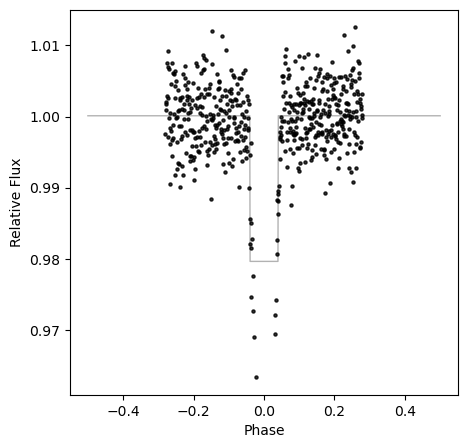

number transit times in baseline: 7  
number of point in each transit:  [4 5 2 3 2 2 1] 
transit likelihood: [ 8.65341875e-04  1.37666736e-03  4.92027570e-04  7.60844171e-04
  2.35478865e-04 -5.68834502e-05  3.11699348e-04]
depths all [0.02048150830989305] transt durations:  [0.08]
Accepted planet: P=3.5817 d
Stopping: insufficient data.
periods to not run again [] rest to run [3.58173221]
len(t0s) 1
3.581732207533787 <class 'numpy.float64'>
periodic, period = 3.581732207533787 days, transits observed =  7
N_intran 28 depth 0.018771930729196886 sig 5.342653880656534e-06
folded: N_intran 0 depth 0.027456698271216825 sig 1000000.0
Sampling attempt 2...


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [t0, Per, a_rs, rp_rs, b]
/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/pytensor/configparser.py:317: UserWarning: PyTensor does not recognise this flag: lock_timeout
  warnings.warn(f"PyTensor does not recognise this flag: {key}")
/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/pytensor/configparser.py:317: UserWarning: PyTensor does not recognise this flag: lock_timeout
  warnings.warn(f"PyTensor does not recognise this flag: {key}")
/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/pytensor/configparser.py:317: UserWarning: PyTensor does not recognise this flag: lock_timeout
  warnings.warn(f"PyTensor does not recognise this flag: {key}")
/users/malharris/miniconda3/envs/envRunningInJupyter/lib/python3.12/site-packages/pytensor/configparser.py:317: UserWarning: PyTensor does not recognise this flag: lock_timeout
  warnings.wa

Output()

<IPython.core.display.HTML object>
<IPython.core.display.HTML object>
<IPython.core.display.HTML object>
<IPython.core.display.HTML object>


Sampling 4 chains for 6_000 tune and 15_000 draw iterations (24_000 + 60_000 draws total) took 39 seconds.


Converged on attempt 3


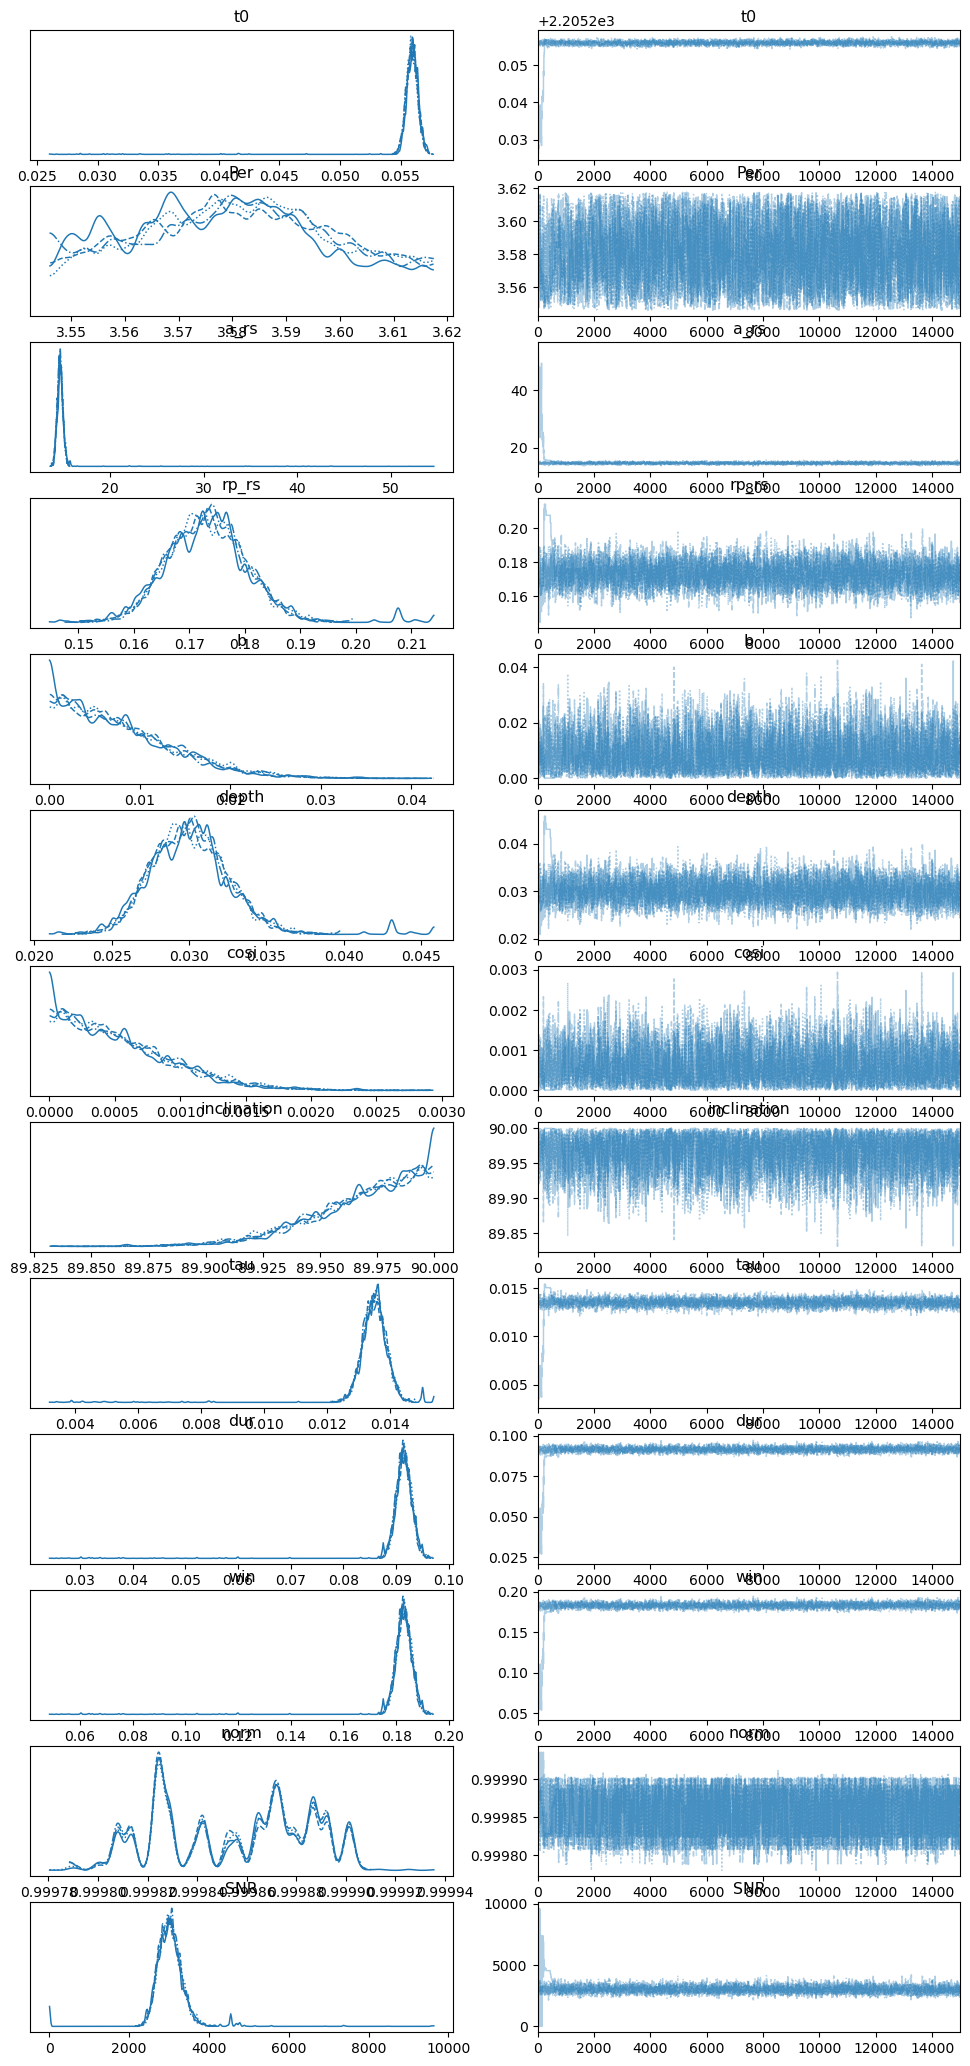

In [ ]:

# import matplotlib_inline
# %matplotlib ipympl
%matplotlib inline

try:
    file_factor = int(0)
except ValueError:
    
    sys.exit(1)
# file_num +=1000

time1 = tm.time()
# target_files = [glob.glob('../toi_data/target*'+str(x)+'*check')[0] for x in missed_ticids]
# target_files = glob.glob('../toi_data/target*check')

# np.random.seed(42)
# main(target_files[-1])

# with Pool(30) as pool:
#     pool.map(main, target_files)

# running_list = list(range(len(target_files)))
# np.random.shuffle(running_list)
# my_file = [x for x in target_files if "163539739" in x]
# # for jjj in bad_target_lst[3:]:
# for jjj in np.array(target_files)[np.array(running_list)]:
# for jjj in np.array(target_files)[:1]:
for jjj in target_files:
    print(jjj)
# #     if "417931300" and "142937186" not in jjj:
# #     try:
#     try:
    main(jjj, conf = 0.55)
#     except: 
#         continue
# #     except Exception as error:
# #         print(error)
# #     gc.collect()
# #     break

time_end = tm.time()

print('DONE!!! time it took: ', (time_end-time1)/60, ' minutes')
